In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

In [11]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
artifact = torch.load(
    "/content/drive/MyDrive/drug_repurposing/models/hetero_gat_artifact.pt",
    map_location="cpu", weights_only=False
)

z_dict = artifact["embeddings"]

comp_emb = z_dict["Compound"]
dis_emb = z_dict["Disease"]

print(comp_emb.shape, dis_emb.shape)

torch.Size([1441, 32]) torch.Size([134, 32])


In [5]:
comp_np = comp_emb.detach().numpy()
dis_np = dis_emb.detach().numpy()

X = np.vstack([comp_np, dis_np])

labels = (
    ["Compound"] * comp_np.shape[0] +
    ["Disease"] * dis_np.shape[0]
)

In [6]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

X_2d = tsne.fit_transform(X)

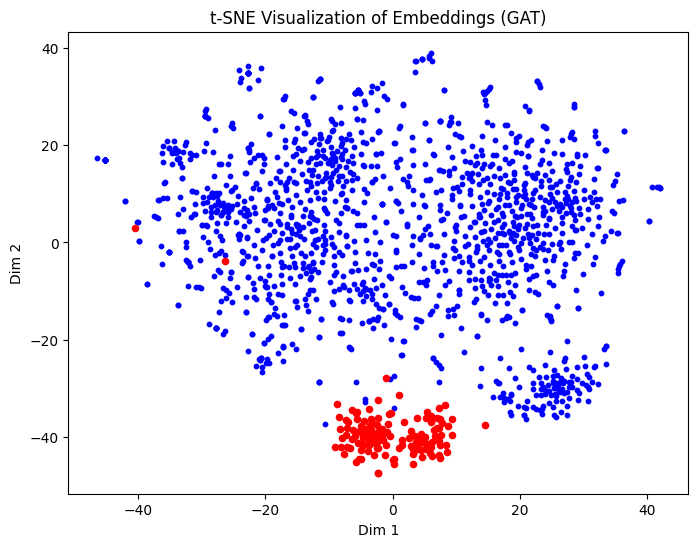

In [7]:
plt.figure(figsize=(8,6))

for i, label in enumerate(labels):
    if label == "Compound":
        plt.scatter(X_2d[i,0], X_2d[i,1], color='blue', s=10)
    else:
        plt.scatter(X_2d[i,0], X_2d[i,1], color='red', s=20)

plt.title("t-SNE Visualization of Embeddings (GAT)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

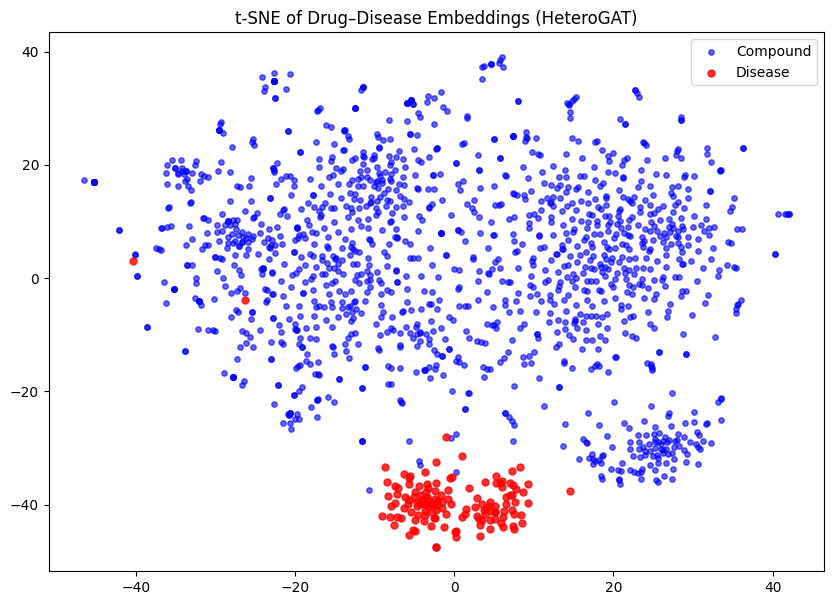

In [8]:
plt.figure(figsize=(10,7))

comp_idx = np.arange(comp_np.shape[0])
dis_idx = np.arange(comp_np.shape[0], X.shape[0])

plt.scatter(X_2d[comp_idx,0], X_2d[comp_idx,1],
            color='blue', label='Compound', alpha=0.6, s=15)

plt.scatter(X_2d[dis_idx,0], X_2d[dis_idx,1],
            color='red', label='Disease', alpha=0.8, s=25)

plt.legend()
plt.title("t-SNE of Drug–Disease Embeddings (HeteroGAT)")
plt.show()

In [12]:
checkpoint = torch.load("/content/drive/MyDrive/drug_repurposing/data/processed/filtered_graph.pt", weights_only=False)

node_maps = checkpoint["node_maps"]
reverse_node_maps = checkpoint["reverse_node_maps"]

disease_name = "Disease::DOID:0050156"

disease_idx = node_maps["Disease"][disease_name]

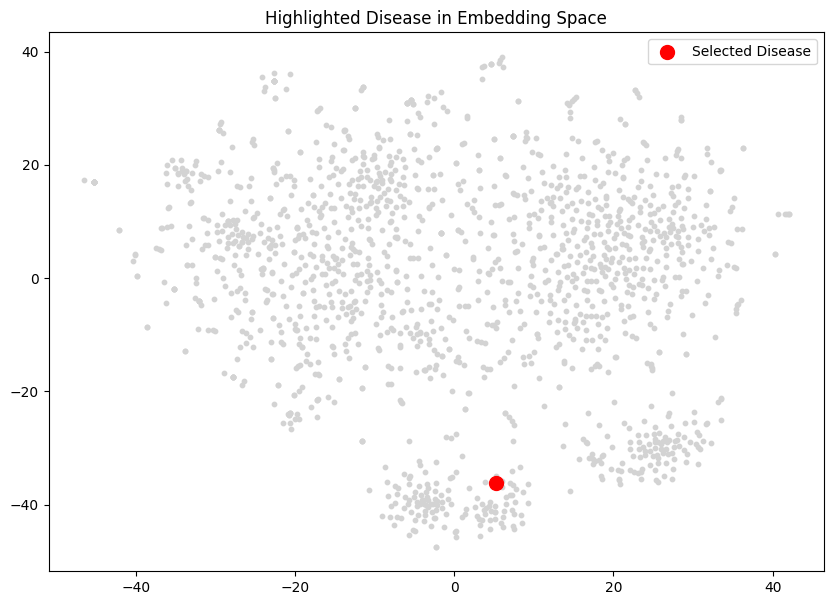

In [13]:
plt.figure(figsize=(10,7))

# plot all
plt.scatter(X_2d[:,0], X_2d[:,1], color='lightgray', s=10)

# highlight disease
d_idx = comp_np.shape[0] + disease_idx
plt.scatter(X_2d[d_idx,0], X_2d[d_idx,1],
            color='red', s=100, label='Selected Disease')

plt.legend()
plt.title("Highlighted Disease in Embedding Space")
plt.show()

In [14]:
def get_top_k_drugs(disease_idx, comp_emb, dis_emb, k=10):

    disease_vec = dis_emb[disease_idx]
    scores = torch.matmul(comp_emb, disease_vec).detach().numpy()

    return np.argsort(-scores)[:k]

In [15]:
top_k = get_top_k_drugs(disease_idx, comp_emb, dis_emb, k=10)

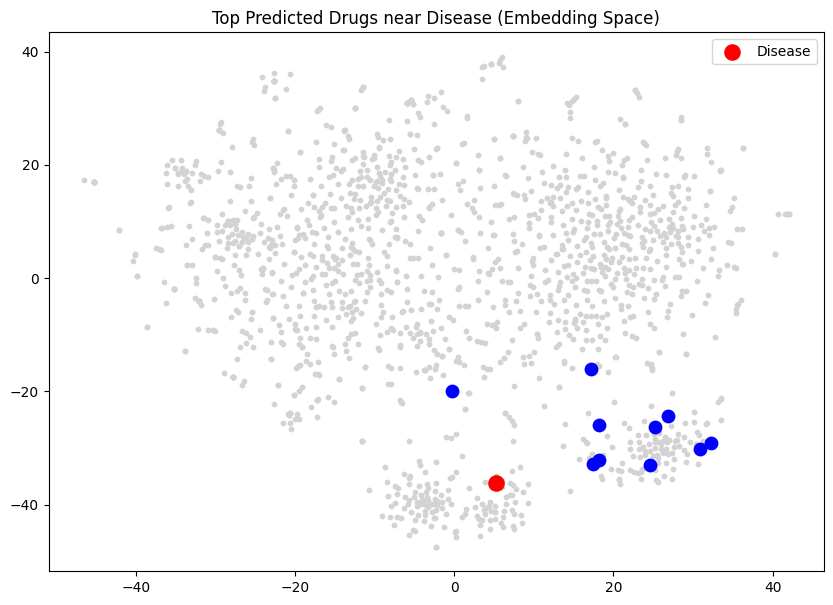

In [16]:
plt.figure(figsize=(10,7))

# all nodes
plt.scatter(X_2d[:,0], X_2d[:,1], color='lightgray', s=10)

# disease
plt.scatter(X_2d[d_idx,0], X_2d[d_idx,1],
            color='red', s=120, label='Disease')

# top drugs
for idx in top_k:
    plt.scatter(X_2d[idx,0], X_2d[idx,1],
                color='blue', s=80)

plt.title("Top Predicted Drugs near Disease (Embedding Space)")
plt.legend()
plt.show()